# Bayesian Validation Results II. Extragalactic Foregrounds and Achromatic Gaussian Beam Perturbations
*A reproducible, open-source framework for assessing the impact of beam‐FWHM uncertainty on 21-cm power spectrum inference*

## Overview  
This notebook presents the pyuvsim, Galactic (GSM) + extragalactic (GLEAM) foregrounds, validation results of the **ValSKA-HERA-beam-FWHM** package. The goals are:  
- Demonstrate how the pipeline verifies the sensitivity of 21-cm power spectrum forward models to errors in the instrument’s primary‐beam FWHM modelling given the new, more accurate foreground model (relative to 01_validation).  
- Provide a reproducible analysis workflow from chain output to key summary figures and statistics.  
- Interpret the results for stakeholders (including instrument teams, pipeline developers, and science leads).

### Usage  
1. Ensure that the pipeline has generated the Markov‐chain/analysis outputs required by the package.  
2. Update the path‐manager and data directories (via `get_default_path_manager()`) to point to your chain outputs.  
3. Run the notebook cells in sequence.  
4. Inspect the generated figures and the Bayesian evidence statistics (BaNTER test) and interpret whether the beam‐modelling error has failed or passed the validation threshold.

### Expected audience  
- Instrument/model-validation scientists working in the 21-cm community  
- Software developers building forward-modelling and inference pipelines  
- STFC / UKSRC project leads reviewing validation status  


## Imports  
Load the required modules from **ValSKA-HERA-beam-FWHM** for plotting, chain handling and Bayesian evidence computation.


In [1]:
from pathlib import Path

from valska_hera_beam.evidence import (
    find_chain_pairs,
    run_complete_bayeseor_analysis,
)
from valska_hera_beam.plotting import BeamAnalysisPlotter
from valska_hera_beam.utils import get_default_path_manager

## Directory and path check  
Before running the analysis, we validate that the default path‐manager has correctly located the required directories (chains, plots, etc).  
This ensures that subsequent steps will reference the correct input/output locations.


In [2]:
# Get path manager with automatic path detection
paths = get_default_path_manager()
# f-print all paths
print(f"{paths=}")

paths=PathManager:
  utils_dir: /share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/src/valska_hera_beam
  package_dir: /share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/src/valska_hera_beam
  base_dir: /share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM
  chains_dir: /share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/chains
  data_dir: /share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/data
  results_dir: /share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/results


## Results

### Reproducing [Burba et al. (2023)](https://academic.oup.com/mnras/article/520/3/4443/7028803?login=false) – Case 1  
In this first validation scenario we replicate the methodology of Burba et al (2023): using a Gaussian fit to the [Burba et al. (2023)](https://academic.oup.com/mnras/article/520/3/4443/7028803?login=false) primary beam and a restricted field‐of‐view.  
- **Expected result**: EoR signal power spectrum is consistent with input (dotted black lines)
- **Noise baseline**: half the EoR signal amplitude  
As an initial check of our power spectrum estimation tooling, we plot the posterior distributions to confirm that our framework reproduces their published outcomes within tolerances.

#### Success criterion  
We consider this reproduction successful if the posterior is consistent at 99% credibility with the published values.


In [3]:
base_chains_dir = Path(paths.chains_dir)
available_chain_pairs = find_chain_pairs(
    base_dir=base_chains_dir / "v7d0/",
    fgeor_prefix="GL_FgEoR_",
    fgonly_prefix="GL_FgOnly_",
)

# Print key and value
for key in available_chain_pairs.keys():
    print(f"Key: {key}, {available_chain_pairs[key].fgeor_root = }")
    print(f"Key: {key}, {available_chain_pairs[key].fgonly_root = }")

Key: -1.0e-01pp, available_chain_pairs[key].fgeor_root = PosixPath('/share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/chains/v7d0/GL_FgEoR_-1.0e-01pp/MN-23-23-38-2-ffm-2.63-2.82-6.2E-03-lp-dPS-v1')
Key: -1.0e-01pp, available_chain_pairs[key].fgonly_root = PosixPath('/share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/chains/v7d0/GL_FgOnly_-1.0e-01pp/MN-23-23-38-2-ffm-2.63-2.82-6.2E-03-lp-dPS-v1')
Key: -1.0e00pp, available_chain_pairs[key].fgeor_root = PosixPath('/share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/chains/v7d0/GL_FgEoR_-1.0e00pp/MN-23-23-38-2-ffm-2.63-2.82-6.2E-03-lp-dPS-v1')
Key: -1.0e00pp, available_chain_pairs[key].fgonly_root = PosixPath('/share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/chains/v7d0/GL_FgOnly_-1.0e00pp/MN-23-23-38-2-ffm-2.63-2.82-6.2E-03-lp-dPS-v1')
Key: -1.0e01pp, available_chain_pairs[key].fgeor_root = PosixPath('/share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/chains/v7d0/GL_F

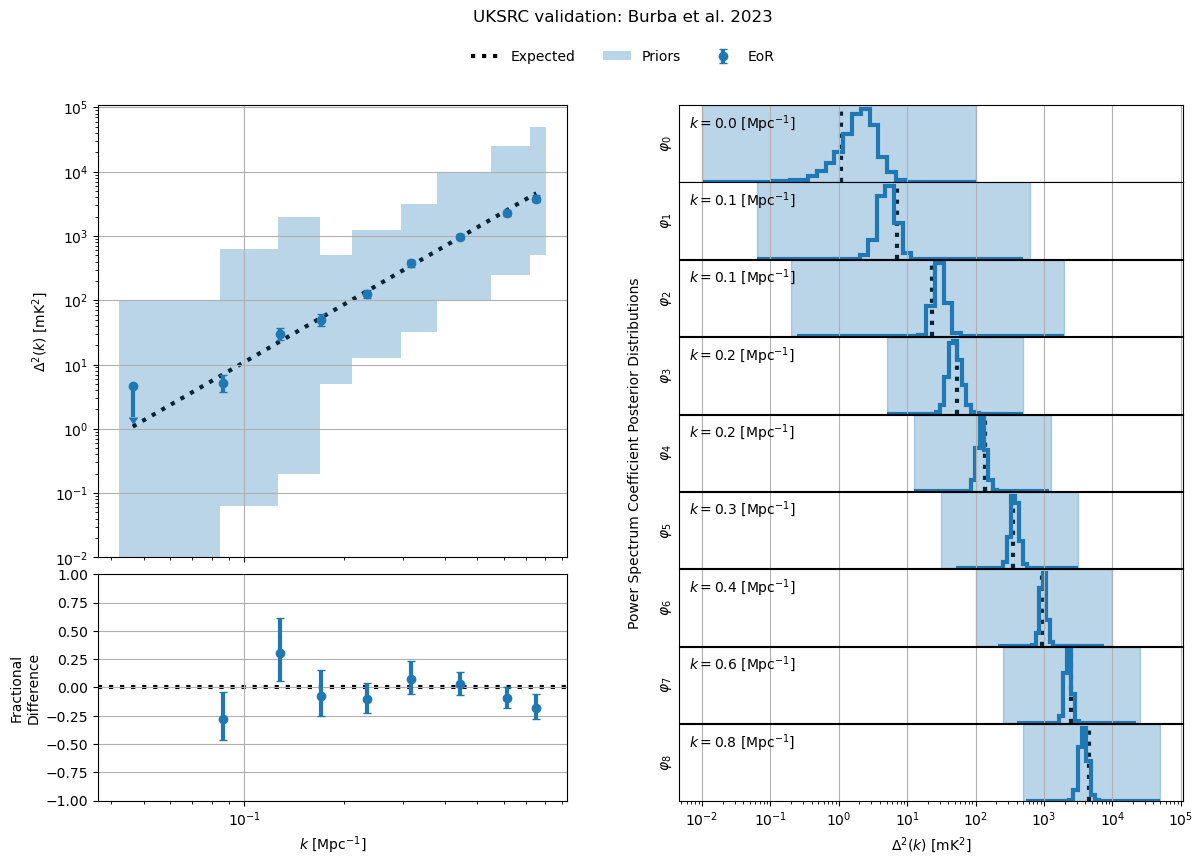

In [4]:
# For EoR signal
expected_ps = 214777.66068216303  # mK^2 Mpc^3
# For foreground-only signal
noise_ps = expected_ps / 2  # mK^2 Mpc^3

base_chains_dir = Path(paths.chains_dir)

# Advanced usage with custom paths and settings
custom_plotter = BeamAnalysisPlotter(
    base_chains_dir=base_chains_dir,
    eor_ps=expected_ps,
    noise_ratio=0.5,
    default_expected_ps=expected_ps,
)

# Find available analysis_keys to plot
# (e.g. EoRFg, EoR, GSM_FgEoR_-1e-3pp etc.) in:
# src/valska_hera_beam/config/paths.yaml
fig = custom_plotter.plot_analysis_results(
    analysis_keys=["EoR"],
    labels=["EoR"],
    expected_ps=expected_ps,
    upper_limit_indices=[0],
)

### HERA Beam-FWHM Sensitivity Study  
In this section we explore how mis-modelling the beam’s Full‐Width at Half‐Maximum (FWHM) impacts our 21-cm power spectrum inference. Using foreground-only validation datasets, we systematically vary the forward‐modelling beam FWHM by ±0.001 %, ±0.01 %, ±0.1 %, ±1 %, ±5 %, ±10 % and examine the posterior recovered power spectra.

> **Key validation logic**: If our pipeline recovers a statistically significant non-zero 21-cm signal (a “detection”) from a pure foreground‐only dataset, this signals a **failure** of the validation test.  
> Conversely, if the posterior is consistent with zero (or with the expected noise baseline), then the model passes for that beam-error level.

#### Workflow  
- Generate posterior chains for each beam-FWHM error setting.  
- Use `BeamAnalysisPlotter.create_comparison_plot()` to visualise relative deviations and credible‐intervals in one combined figure.  
- Label each error scenario clearly and compare to the expected noise baseline.

#### Interpretation  
We will identify the maximum beam‐FWHM error for which the validation test still **passes**. That threshold informs the instrument modelling budget: beam-FWHM knowledge must be better than that threshold to avoid spurious detections.


GSM + GLEAM -10%: ['GL_FgEoR_-1.0e01pp']
GSM + GLEAM -5%: ['GL_FgEoR_-5.0e00pp']
GSM + GLEAM -1%: ['GL_FgEoR_-1.0e00pp']
GSM + GLEAM -0.1%: ['GL_FgEoR_-1.0e-01pp']
GSM + GLEAM +0.1%: ['GL_FgEoR_1.0e-01pp']
GSM + GLEAM +1%: ['GL_FgEoR_1.0e00pp']
GSM + GLEAM +5%: ['GL_FgEoR_5.0e00pp']
GSM + GLEAM +10%: ['GL_FgEoR_1.0e01pp']


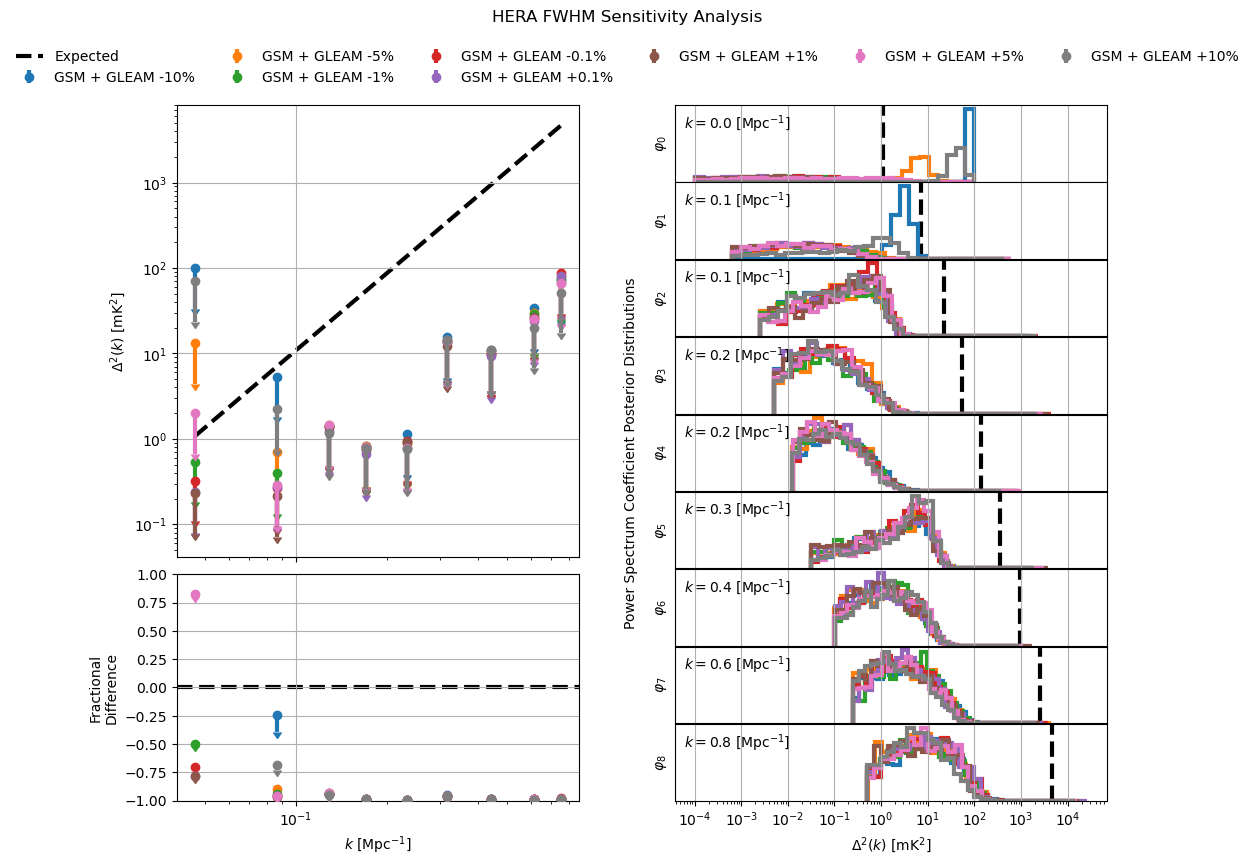

In [5]:
# Create a complex comparison plot

from valska_hera_beam.utils import (
    build_group_labels,
    build_pp_groups_from_paths,
)

groups = build_pp_groups_from_paths(
    # prefixes=["GSM_FgEoR_", "GL_FgEoR_"],
    # label_prefixes={"GSM_FgEoR_": "GSM", "GL_FgEoR_": "GSM + GLEAM"},
    prefixes=["GL_FgEoR_"],
    label_prefixes={"GL_FgEoR_": "GSM + GLEAM"},
)

group_labels = build_group_labels(groups)

# Print the groups found
for label, keys in groups.items():
    print(f"{label}: {keys}")


fig = custom_plotter.create_comparison_plot(
    groups=groups,
    # 1. Fix the expected label
    expected_label="Expected Noise Level",
    # 2. Set upper limit indices (all analyses will use these by default)
    upper_limit_indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    # 3. Specify GSM -10% zeroth k-mode as a detection, not an upper limit
    detection_indices={"GSM_FgEoR_-1e1pp": [0]},
    # Other parameters
    figsize=(12, 10),
    plot_fracdiff=True,
    plot_priors=False,
    group_labels=group_labels,
    # Customize the expected line style if desired
    ls_expected="--",
)

### BaNTER (Bayesian Evidence Null-Test Evidence Ratio) Analysis  
Here we compute the **BaNTER statistic**, which is the ratio of Bayesian evidences between two competing models:  
- *Model 1*: foreground-only model  
- *Model 2*: foreground + EoR model  

A large Bayes-factor in favour of the EoR model (despite the dataset being foreground‐only) would indicate a **validation failure** (spurious “detection”). We compute this ratio for all chain-pairs generated in the study and summarise both the numerical results and their implications.

#### Workflow  
- Use `find_chain_pairs()` to locate matching chain pairs (FgOnly vs FgEoR) across each error scenario.  
- Run `run_complete_bayeseor_analysis()` to accumulate the evidence statistics for all pairs.  
- Inspect the resulting Bayes‐factors using `calculate_bayes_factor()` and interpret with the decision rule:  
  - If BF ≫ 1 in favour of EoR: **fail**.  
  - If BF = 1 or < 1 favouring foreground-only: **pass**.

#### Output  
The notebook will print a listing of chain‐pair keys and output the Bayes‐factor for an example pair, illustrating how to extract and interpret results for all scenarios.


In [6]:
# Example: v7d0 pair-based analysis
print(f"{paths.chains_dir=}")

chains_dir = paths.chains_dir

# v7_base
base = chains_dir / "v7d0"
fgeor_prefix = ("GL_FgEoR_",)  # This is GSM + GLEAM
fgonly_prefix = ("GL_FgOnly_",)  # This is GSM + GLEAM

print("=== Discovering v7d0 chain pairs ===")
pairs = find_chain_pairs(
    base,
    fgeor_prefix=fgeor_prefix,
    fgonly_prefix=fgonly_prefix,
    # debug=True,
)
print(f"Found {len(pairs)} pairs:", list(pairs.keys()))

print("Found pairs:")
for key, pair in pairs.items():
    print(
        key,
        "=>",
        "FgEoR:",
        pair.fgeor_root,
        "FgOnly:",
        pair.fgonly_root,
    )

print("=== Example: Complete analysis over all discovered pairs ===")
results = run_complete_bayeseor_analysis(
    chain_pairs=pairs,
    create_plots=False,
    verbose=True,
    # dir_prefix=paths.chains_dir,
)

paths.chains_dir=PosixPath('/share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/chains')
=== Discovering v7d0 chain pairs ===
Found 8 pairs: ['-1.0e-01pp', '-1.0e00pp', '-1.0e01pp', '-5.0e00pp', '1.0e-01pp', '1.0e00pp', '1.0e01pp', '5.0e00pp']
Found pairs:
-1.0e-01pp => FgEoR: /share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/chains/v7d0/GL_FgEoR_-1.0e-01pp/MN-23-23-38-2-ffm-2.63-2.82-6.2E-03-lp-dPS-v1 FgOnly: /share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/chains/v7d0/GL_FgOnly_-1.0e-01pp/MN-23-23-38-2-ffm-2.63-2.82-6.2E-03-lp-dPS-v1
-1.0e00pp => FgEoR: /share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/chains/v7d0/GL_FgEoR_-1.0e00pp/MN-23-23-38-2-ffm-2.63-2.82-6.2E-03-lp-dPS-v1 FgOnly: /share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/chains/v7d0/GL_FgOnly_-1.0e00pp/MN-23-23-38-2-ffm-2.63-2.82-6.2E-03-lp-dPS-v1
-1.0e01pp => FgEoR: /share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/chains/v7d0/GL_F

Analyzing perturbations:   0%|                          | 0/8 [00:00<?, ?case/s]

Analyzing: 5.0e00pp: 100%|██████████████████████| 8/8 [00:01<00:00,  5.69case/s]


COMPLETE BAYESEOR PERTURBATION ANALYSIS SUMMARY
Perturbation         Log BF     Validation   Interpretation
--------------------------------------------------------------------------------
-1.0e-01pp           -7.441     ✅ PASS          Very strong evidence for model 2
-1.0e00pp            -7.254     ✅ PASS          Very strong evidence for model 2
-1.0e01pp            149.362    ❌ FAIL          Very strong evidence for model 1
-5.0e00pp            -0.118     ✅ PASS          Weak/inconclusive evidence
1.0e-01pp            -7.301     ✅ PASS          Very strong evidence for model 2
1.0e00pp             -6.915     ✅ PASS          Very strong evidence for model 2
1.0e01pp             36.554     ❌ FAIL          Very strong evidence for model 1
5.0e00pp             -6.566     ✅ PASS          Very strong evidence for model 2
--------------------------------------------------------------------------------
TOTAL: 8 cases | PASS: 6 | FAIL: 2 | ERROR: 0
⚠️  SOME CASES FAILED BaNTER VALIDATION -

In [7]:
from valska_hera_beam.evidence import calculate_bayes_factor

# key = "+1e-1pp"
key = list(pairs.keys())[0]
pair = pairs[key]

bf = calculate_bayes_factor(
    chain_path_1=pair.fgeor_root / "data-",
    chain_path_2=pair.fgonly_root / "data-",
    model_name_1=f"GL_FgEoR_{key}",
    model_name_2=f"GL_FgOnly_{key}",
    verbose=True,
)
print(bf)

Loading GL_FgEoR_-1.0e-01pp chain from: /share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/chains/v7d0/GL_FgEoR_-1.0e-01pp/MN-23-23-38-2-ffm-2.63-2.82-6.2E-03-lp-dPS-v1/data-
GL_FgEoR_-1.0e-01pp log evidence: 1110983925883.707520
Loading GL_FgOnly_-1.0e-01pp chain from: /share/nas-0-3/psims/test/UKSRC/validation/ValSKA-HERA-beam-FWHM/chains/v7d0/GL_FgOnly_-1.0e-01pp/MN-23-23-38-2-ffm-2.63-2.82-6.2E-03-lp-dPS-v1/data-
GL_FgOnly_-1.0e-01pp log evidence: 1110983925891.148193
Log Bayes Factor (ln(GL_FgEoR_-1.0e-01pp/GL_FgOnly_-1.0e-01pp)): -7.440674
Interpretation: Very strong evidence for model 2
{'model_1': 'GL_FgEoR_-1.0e-01pp', 'model_2': 'GL_FgOnly_-1.0e-01pp', 'log_evidence_1': 1110983925883.7075, 'log_evidence_2': 1110983925891.1482, 'log_bayes_factor': -7.440673828125, 'interpretation': 'Very strong evidence for model 2', 'success': True, 'error': None}


## Summary & Conclusions  
- We successfully reproduced Case 1 of Burba et al (2023) with agreement within numerical precision of the nested sampling.  
- In the GSM + GLEAM beam-FWHM sensitivity analysis, the pipeline remains **robust** for beam‐FWHM errors up to +/-5%, which is a lower tolerance than in the lower-fidelity GSM-only sky analysis.  
- Beyond that threshold, the validation test fails due to spurious power‐spectrum detections or excessively large Bayes-factors.  
- Recommended next steps:  
  1. Extend the analysis to include non-Gaussian beam fits and realistic beam‐error distributions.  
  2. Incorporate full simulation‐to‐inference chain variations (e.g., baseline errors, calibration offsets).  
- **Implication for the instrument-validation workflow**: Under the approximations made here the Beam-FWHM must be known to better than +/-5% to ensure reliable EoR inference from a forward modelling data analysis using HERA‐style arrays.

## How to re-use this notebook  
- Modify the `paths` or `chain_dir` variables to match your local directory structure.  
- Use `create_comparison_plot()` and `run_complete_bayeseor_analysis()` as templates for additional error‐scenarios.  
- Save figures and Bayes-factor summaries to your project.
